In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/abrasions (85).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/abrasions (55).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/mirrored_abrasions (40).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/abrasions (28).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/abrasions (9).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/abrasions (69).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/abrasions (39).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/abrasions (60).jpg
/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy/Abrasions/mirrored_abrasions (20).jpg
/kaggle/input/datasets/ibrahi

In [2]:
import os
import glob

pardir_path=r'/kaggle/input/datasets/ibrahimfateen/wound-classification/Wound_dataset copy'
pardir_ls=os.listdir(pardir_path)
print(pardir_ls)

['Abrasions', 'Cut', 'Burns', 'Normal', 'Laseration', 'Diabetic Wounds', 'Pressure Wounds', 'Surgical Wounds', 'Bruises', 'Venous Wounds']


In [3]:
child_files_dict = {}
print("-------------------------------------------------")
for catg in pardir_ls:
    print("Category:", catg)
    files = os.listdir(f"{pardir_path}/{catg}")[:10]  # take first 10
    child_files_dict[catg] = files                    # store list of 10
    for i, file in enumerate(files, start=1):
        print(i, ".", file)
    print("-------------------------------------------------")

-------------------------------------------------
Category: Abrasions
1 . abrasions (85).jpg
2 . abrasions (55).jpg
3 . mirrored_abrasions (40).jpg
4 . abrasions (28).jpg
5 . abrasions (9).jpg
6 . abrasions (69).jpg
7 . abrasions (39).jpg
8 . abrasions (60).jpg
9 . mirrored_abrasions (20).jpg
10 . abrasions (70).jpg
-------------------------------------------------
Category: Cut
1 . cut (8).jpg
2 . mirrored_cut (47).jpg
3 . mirrored_cut (46).jpg
4 . cut (16).jpg
5 . cut (13).jpg
6 . cut (31).jpg
7 . mirrored_cut (39).jpg
8 . cut (50).jpg
9 . mirrored_cut (14).jpg
10 . cut (17).jpg
-------------------------------------------------
Category: Burns
1 . burns (25).jpg
2 . case2-burns-to-arm-7.jpg
3 . burns (15).jpg
4 . burns (29).jpg
5 . mirrored_burns (13).jpg
6 . mirrored_burns (3).jpg
7 . mirrored_case6-burn-to-shoulder.jpg
8 . mirrored_burns (7).jpg
9 . mirrored_burns (41).jpg
10 . mirrored_burns (15).jpg
-------------------------------------------------
Category: Normal
1 . mirrored_3

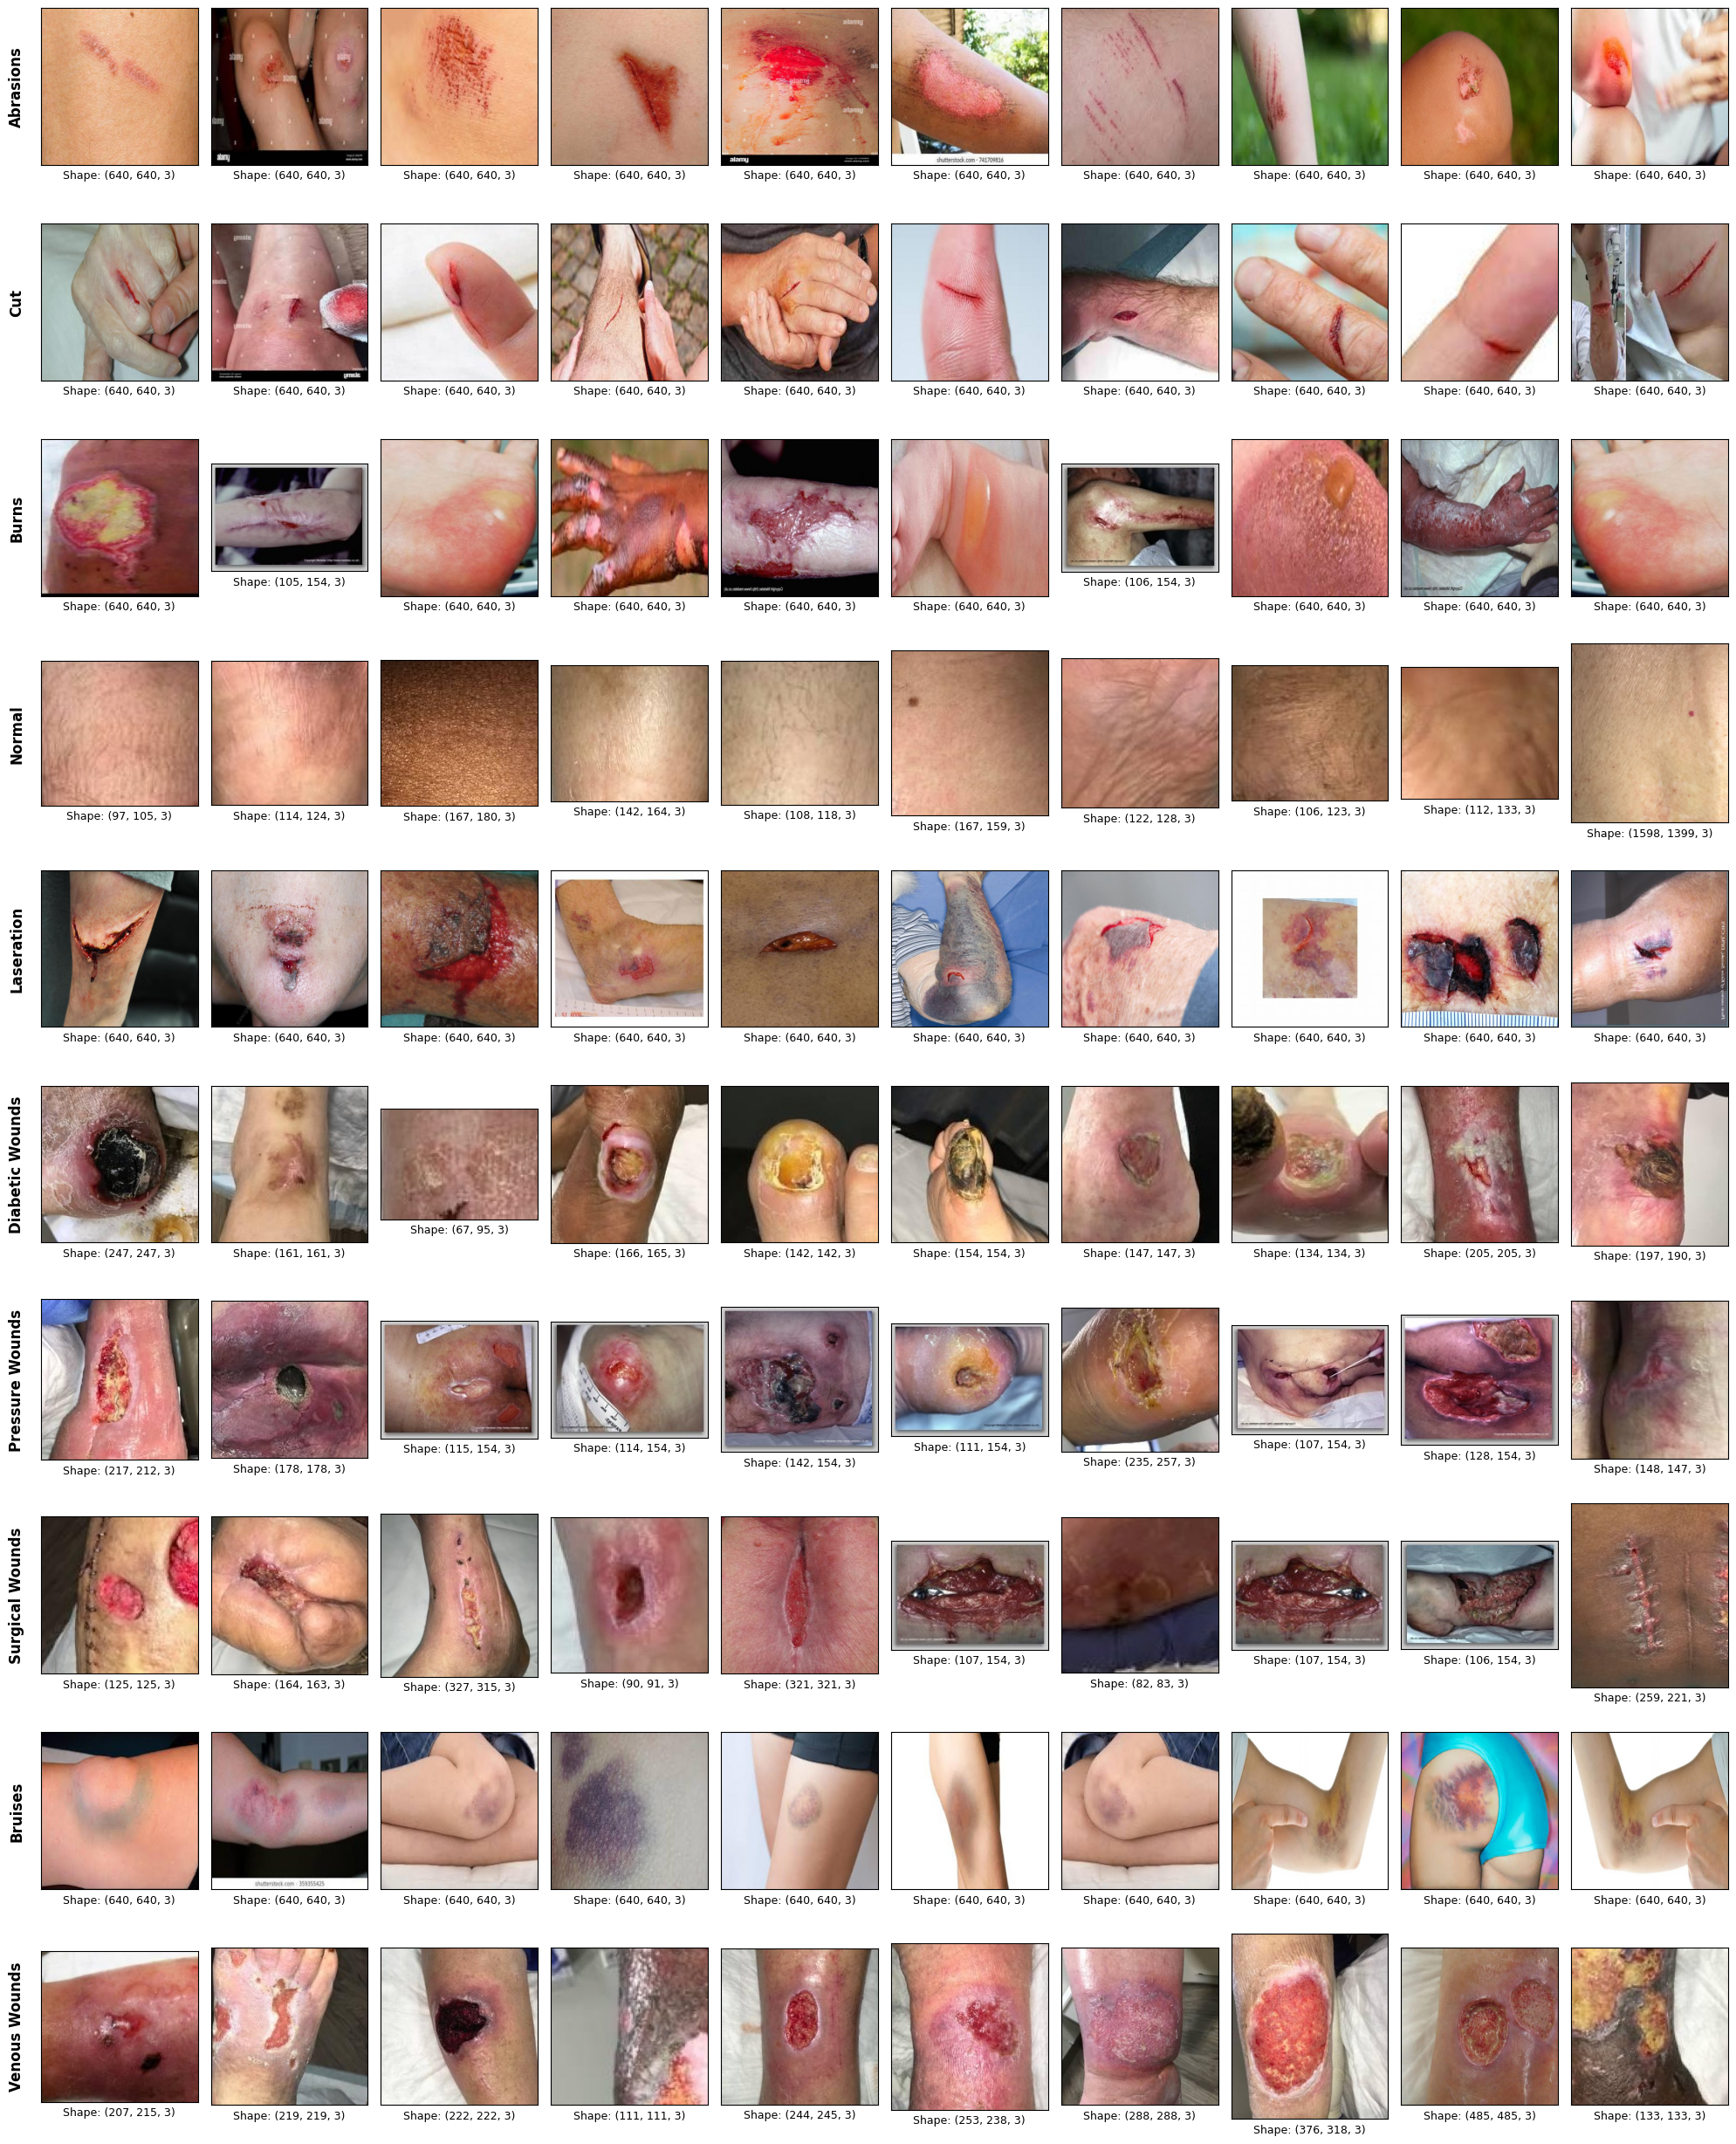

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

n_catg = len(child_files_dict)
image_shape_10_samples=[]

# squeeze=False guarantees 'axes' is ALWAYS a 2D array, even if n_catg is 1
fig, axes = plt.subplots(nrows=n_catg, ncols=10, figsize=(20, 2.5 * n_catg), squeeze=False)

for row_idx, (catg, files) in enumerate(child_files_dict.items()):
    # Slice files[:10] to safely prevent IndexError if a folder has > 10 images
    for col_idx, file in enumerate(files[:10]):
        ax = axes[row_idx][col_idx]
        img_path = os.path.join(pardir_path, catg, file)
        
        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.set_xlabel(f"Shape: {img.shape}", fontsize=9)
            image_shape_10_samples.append(img.shape)
        except Exception as e:
            ax.text(0.5, 0.5, "Load Error", ha='center', va='center')
            print(f"Error loading {img_path}: {e}")
        
        # Only set the category label on the very first column of the row
        if col_idx == 0:
            ax.set_ylabel(catg, rotation=90, labelpad=20, va='center', fontweight='bold', fontsize=12)
            
        # Clean up pixel ticks so the grid looks sharp and readable
        ax.set_xticks([])
        ax.set_yticks([])

    # If a category has fewer than 10 images, hide the remaining empty subplots in the row
    for col_idx in range(len(files), 10):
        axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.show()

In [5]:
image_shape_10_samples

[(640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (105, 154, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (106, 154, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (97, 105, 3),
 (114, 124, 3),
 (167, 180, 3),
 (142, 164, 3),
 (108, 118, 3),
 (167, 159, 3),
 (122, 128, 3),
 (106, 123, 3),
 (112, 133, 3),
 (1598, 1399, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (640, 640, 3),
 (247, 247, 3),
 (161, 161, 3),
 (67, 95, 3),
 (166, 165, 3),
 (142, 142, 3),
 (154, 154, 3),
 (147, 147, 3),
 (134, 134, 3),
 (205, 205, 3),
 (197, 190, 3),
 (217, 212, 3),
 (178, 178, 3),
 (115, 15

### Check For Class Imbalance

In [6]:
for catg in pardir_ls:
    print("Category:", catg)
    files = os.listdir(f"{pardir_path}/{catg}")
    print(len(files))

Category: Abrasions
164
Category: Cut
100
Category: Burns
134
Category: Normal
200
Category: Laseration
122
Category: Diabetic Wounds
462
Category: Pressure Wounds
602
Category: Surgical Wounds
420
Category: Bruises
242
Category: Venous Wounds
494


In [7]:
# Utility function to visualize matching pairs from 2 images

# import cv2
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# import gc
# import os

# def visualize_matches(image1_path, image2_path, max_lines=200):
#     # --- 1. Memory Cleanup ---
#     plt.close('all')
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

#     def process_background(path):
#         # Load image including alpha channel (BGRA)
#         img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
#         if img is None:
#             return None, None
        
#         # Check if the image has an alpha (transparency) channel
#         if img.shape[2] == 4:
#             b, g, r, a = cv2.split(img)
#             # Create a mask from the alpha channel (0 = transparent, 255 = opaque)
#             mask = a 
#             # Merge BGR channels and fill transparent areas with pure black (0, 0, 0)
#             img_rgb = cv2.merge([b, g, r])
#             img_rgb[mask == 0] = 0 
#             # Convert to grayscale for feature extraction
#             img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
#             return img_gray, img_rgb
#         else:
#             # If no alpha channel, proceed with standard conversion
#             img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#             # Ensure the visualization image is in BGR for consistency
#             img_vis = img if img.shape[2] == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
#             return img_gray, img_vis

#     # --- 2. Run Background Removal Process ---
#     img1_gray, img1_vis = process_background(image1_path)
#     img2_gray, img2_vis = process_background(image2_path)

#     if img1_gray is None or img2_gray is None:
#         print("Error: Could not load images.")
#         return

#     # --- 3. Tensor Conversion ---
#     # Use .clone() to ensure fresh memory allocation
#     t1 = torch.from_numpy(img1_gray).float().clone().to(device) / 255.0
#     t2 = torch.from_numpy(img2_gray).float().clone().to(device) / 255.0
#     t1 = t1.unsqueeze(0).unsqueeze(0)
#     t2 = t2.unsqueeze(0).unsqueeze(0)

#     # --- 4. Matching (Black background ensures only the animal is targeted) ---
#     with torch.no_grad():
#         f1_raw = extractor.extract(t1)
#         f2_raw = extractor.extract(t2)
#         m01_raw = matcher({'image0': f1_raw, 'image1': f2_raw})

#     f1, f2, m01 = [rbd(x) for x in [f1_raw, f2_raw, m01_raw]]
#     kpts1, kpts2 = f1['keypoints'].cpu().numpy(), f2['keypoints'].cpu().numpy()
#     matches = m01['matches'].cpu().numpy()

#     valid = matches > -1
#     idx1, idx2 = np.where(valid)[0], matches[valid]

#     # Limit the number of lines for clarity
#     if len(idx1) > max_lines:
#         sel = np.random.choice(len(idx1), max_lines, replace=False)
#         idx1, idx2 = idx1[sel], idx2[sel]

#     # --- 5. Create Visualization Canvas ---
#     # Use the color images where the background has been physically removed (blacked out)
#     h1, w1 = img1_vis.shape[:2]
#     h2, w2 = img2_vis.shape[:2]
#     canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
#     canvas[:h1, :w1] = img1_vis
#     canvas[:h2, w1:] = img2_vis

#     # --- 6. Draw Matching Lines ---
#     for i1, i2 in zip(idx1, idx2):
#         pt1 = (int(kpts1[i1][0]), int(kpts1[i1][1]))
#         pt2 = (int(kpts2[i2][0]) + w1, int(kpts2[i2][1]))
#         # Generate random colors for each line
#         color = tuple(map(int, np.random.randint(0, 255, 3)))
#         cv2.line(canvas, pt1, pt2, color, 1, cv2.LINE_AA)

#     # --- 7. Display Results ---
#     plt.figure(figsize=(15, 8))
#     plt.imshow(canvas[:, :, ::-1]) # Convert BGR to RGB for matplotlib
#     plt.title(f"Animal-only Matching: {len(idx1)} points")
#     plt.axis("off")
#     plt.show()

#     # Explicit memory cleanup for local variables
#     del img1_gray, img2_gray, canvas, t1, t2

**Images are much heavier. If we try to load all 2,940 of our irregular raw images into RAM simultaneously, our notebook would immediately crash with an Out Of Memory (OOM) error.**

Instead of loading pixels, image_dataset_from_directory acts as a smart folder manager: Thus it does not read the actual image pixels yet. It creates a lazy-loading streaming pipeline (tf.data.Dataset). Only when the model starts training does it open the files off our drive, 32 at a time, resize those specific 32 images to $224 \times 224$, and pass them to the processor.

In [8]:
import tensorflow as tf
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.utils import image_dataset_from_directory

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATASET_DIR = pardir_path

# Transformed image dataset 
train_ds=image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int' # Returns integer labels for sparse categorical cross-entropy
)

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Extract class names to assign int labels to each class
class_names = train_ds.class_names
print("Found classes:", class_names)

2026-06-11 06:18:54.776443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781158735.089383      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781158735.168237      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781158735.833903      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781158735.833944      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781158735.833947      16 computation_placer.cc:177] computation placer alr

Found 2940 files belonging to 10 classes.
Using 2352 files for training.
Found 2940 files belonging to 10 classes.
Using 588 files for validation.


2026-06-11 06:19:13.488783: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found classes: ['Abrasions', 'Bruises', 'Burns', 'Cut', 'Diabetic Wounds', 'Laseration', 'Normal', 'Pressure Wounds', 'Surgical Wounds', 'Venous Wounds']


In [9]:
# Pull just 1 batch from the streaming pipeline
for image_batch, label_batch in train_ds.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Example of data type in images:", image_batch.dtype)
    print("Example of labels in this batch:", label_batch.numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Example of data type in images: <dtype: 'float32'>
Example of labels in this batch: [4 3 4 0 9 8 9 1 9 9 7 7 1 9 6 1 4 8 9 5 4 8 7 4 4 8 9 7 6 0 4 5]


In [10]:
# 1. Find out exactly how many batches are on the validation set
total_val_batches = val_ds.cardinality().numpy()

# 2. Calculate half of the batches (using integer division //)
test_batches = total_val_batches // 2

# 3. Slice the conveyor belt cleanly without loading anything into memory
test_ds = val_ds.take(test_batches)       # Takes the first half of batches
val_ds_final = val_ds.skip(test_batches)  # Keeps the remaining batches

# 4. Verify the new pipeline splits
print(f"Original validation batches: {total_val_batches}")
print(f"Final Validation batches (for training checks): {val_ds_final.cardinality().numpy()}")
print(f"Testing batches (for the final blind exam): {test_ds.cardinality().numpy()}")

Original validation batches: 19
Final Validation batches (for training checks): 10
Testing batches (for the final blind exam): 9


**Augmentation Stage**

The data from Robot's camera sensor might not be regular or uniform, thus we shall also augment our training data with rotated, flipped and other transformed images for bettergeneralization

In [11]:
from tensorflow.keras import layers, Model

# Creating the pipeline of transformations for augmentation of images
trans_pipeline = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15), # 15% deviation
    layers.RandomZoom(0.1) # 1% deviation
])

**Transfer Learning**

We shall use MobileNetV3Small model pretrained on ImageNet data and fine tune it oin our training data and test it

In [12]:
# Load MobileNetV3-Small
base_model=tf.keras.applications.MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False, # remove the  top layer of classification as we shall have our own training layers
    weights='imagenet'
)

base_model.trainable=False # Since the model has already been pre trained on a huge dataset of Imagenet, we don't want backpropagation to update its precomputed weights or biases during training on our small 2940 dataset
# So we freeze the feature extraction backbone while we shall personalise the classification layer by training the model on our data 

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Let's now create the entire model blueprint, the base_model layer from MobileNetV3 + the outer classification layer**

In [13]:
inputs=layers.Input(shape=(224,224,3))

# data augmentation stage fit
x=trans_pipeline(inputs)

# Apply MobileNetV3's internal preprocessing (scales pixels between -1 and 1)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

# Pass the images through the frozen backbone (training=False locks batchnorm layers)
x = base_model(x, training=False)

# Collapse the spatial dimensions (2D image maps) into a flat vector of features
x = layers.GlobalAveragePooling2D()(x)

# The New Trainable Head: 10 outputs (one for each wound class) with Softmax probabilities
outputs = layers.Dense(10, activation='softmax')(x)

# Construct the final functional model
model = Model(inputs=inputs, outputs=outputs)

# Print the architectural blueprint
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,890 (3.60 MB)

 Trainable params: 5,770 (22.54 KB)

 Non-trainable params: 939,120 (3.58 MB)

**Why the GlobalAveragePolling layer??**

When the data exits the frozen MobileNetV3 backbone, it isn't a flat list of numbers. It is a 3D block of "feature maps"—specifically, a matrix of shape (7, 7, 576). This means the network has extracted 576 different abstract medical textures, and each texture is mapped onto a small $7 \times 7$ spatial grid.To hand this data to our final 10-class Dense layer, we must transform this 3D block into a 1D vector. 


We have two ways to do this:

---
Option A: The Flatten LayerFlatten takes every single pixel in that 3D block and strings them out into one giant line.

The Math: $7 \times 7 \times 576 = 28,224$ values.

The Problem: If you connect a vector of $28,224$ inputs directly to your final $10$ output neurons, that single layer will require over 282,000 trainable weights ($28,224 \times 10$).For your Raspberry Pi 4B, this is dangerous. It dramatically inflates the file size, slows down CPU computation speeds, and makes the model highly prone to overfitting on your small dataset.

---

Option B: The GlobalAveragePooling2D LayerInstead of keeping every pixel, this layer looks at each of the 576 feature maps (each of size $7 \times 7$), calculates the average value of those 49 pixels, and squashes it down to a single number.

The Math: A $(7, 7, 576)$ tensor instantly shrinks to a clean vector of just 576 values.

The Benefit: Connecting 576 inputs to 10 outputs requires only 5,760 trainable weights ($576 \times 10$).

Why we use it for the Robot: By choosing Global Average Pooling, you slash the parameter count of your classification head by 98%. This keeps our model incredibly lightweight, prevents the model from memorizing specific pixel locations, and ensures your TFLite model executes on the Pi 4 CPU in milliseconds.

---

In [14]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print("Model successfully compiled!")

Model successfully compiled!


The optimizer is the algorithm that adjusts the 5,770 weights of our classification head based on the errors it makes. Adam is the gold standard because it uses "adaptive momentum"—it automatically speeds up or slows down its learning pace depending on how fast the model is improving. A learning rate of 0.001 is standard and safe for an initial transfer learning phase.

We use the Sparse version specifically because of how we set up our datasets earlier (label_mode='int'). Your data streams raw integers (like 3 for Burns). If our data streamed hot-encoded vectors (like [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]), you would drop the word "Sparse".



In [15]:
# 1. Unpack only the integer labels from the training pipeline stream
# This skims the conveyor belt to gather the target values (y) without holding images in RAM
y_train = np.concatenate([y.numpy() for x, y in train_ds], axis=0)

# 2. Compute balanced weights using scikit-learn's mathematical formula
computed_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 3. Turn the weights into a dictionary format Keras demands: {class_integer: multiplier_value}
class_weight_dict = dict(enumerate(computed_weights))

# 4. Print the map to inspect how the penalties look
print("Class Weight Magnitudes:\n" + "-"*30)
for class_index, weight in class_weight_dict.items():
    print(f"Class {class_index} ({class_names[class_index]}): {weight:.4f}")

Class Weight Magnitudes:
------------------------------
Class 0 (Abrasions): 1.8233
Class 1 (Bruises): 1.2062
Class 2 (Burns): 2.2400
Class 3 (Cut): 2.9772
Class 4 (Diabetic Wounds): 0.6189
Class 5 (Laseration): 2.4500
Class 6 (Normal): 1.4700
Class 7 (Pressure Wounds): 0.4931
Class 8 (Surgical Wounds): 0.6798
Class 9 (Venous Wounds): 0.6109


Due to the lass imbalance we have, we resort to building a multiplier, that adjusts the weight for each class so that the model gives equal priority to all the classes

"Cut" (100 images) will receive a high weight value (likely around 2.9).

"Pressure Wounds" (602 images) will receive a low weight value (likely around 0.4).

In [16]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds_final, 
    epochs=EPOCHS,
    class_weight=class_weight_dict # Injecting our imbalance multipliers
)

Epoch 1/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 37s 417ms/step - accuracy: 0.3737 - loss: 1.8548 - val_accuracy: 0.5533 - val_loss: 1.3988
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 395ms/step - accuracy: 0.5969 - loss: 1.2730 - val_accuracy: 0.5933 - val_loss: 1.2177
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 382ms/step - accuracy: 0.6441 - loss: 1.0677 - val_accuracy: 0.6533 - val_loss: 1.0703
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 393ms/step - accuracy: 0.6832 - loss: 0.9406 - val_accuracy: 0.6933 - val_loss: 1.0016
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 376ms/step - accuracy: 0.7126 - loss: 0.8444 - val_accuracy: 0.7133 - val_loss: 0.8773
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 385ms/step - accuracy: 0.7385 - loss: 0.7685 - val_accuracy: 0.7433 - val_loss: 0.8499
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 380ms/step - accuracy: 0.7355 - loss: 0.7348 - val_accuracy: 0.7567 - val_loss: 0.7654
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 372ms/step - accuracy: 0.7572 - loss: 0.6937 - val_accu

In [17]:
print("1. Accuracy: ",(max(history.history['accuracy']))*100)
print("   Val_accuracy: ",(max(history.history['val_accuracy']))*100)
print("")
print("2. Loss: ",(min(history.history['loss']))*100)
print("   Val_loss: ",(min(history.history['val_loss']))*100)

print("------------------------------------")
print("15th epoch: ")
print("1. Accuracy: ",((history.history['accuracy'][-1]))*100)
print("   Val_accuracy: ",((history.history['val_accuracy'][-1]))*100)
print("")
print("2. Loss: ",((history.history['loss'][-1]))*100)
print("   Val_loss: ",((history.history['val_loss'][-1]))*100)

1. Accuracy:  80.69728016853333
   Val_accuracy:  76.99999809265137

2. Loss:  52.08730101585388
   Val_loss:  68.58737468719482
------------------------------------
15th epoch: 
1. Accuracy:  80.69728016853333
   Val_accuracy:  76.33333206176758

2. Loss:  52.08730101585388
   Val_loss:  68.58737468719482


Text(0.5, 1.0, 'Accuracy v/s val_accuracy for baseline model')

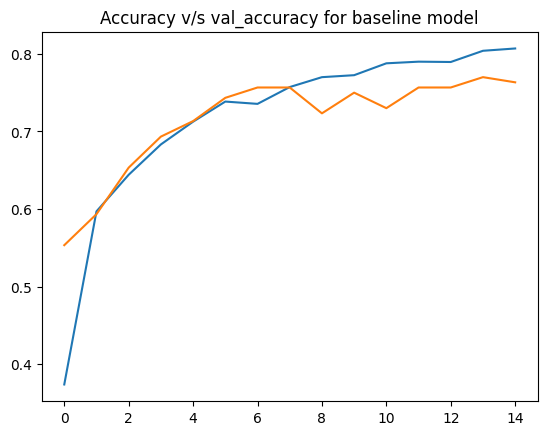

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy v/s val_accuracy for baseline model")

Text(0.5, 1.0, 'Loss v/s val_loss for baseline model')

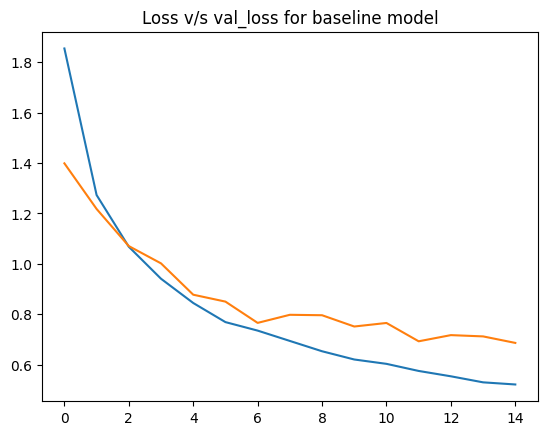

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss v/s val_loss for baseline model")

**Improvements** - we didn't tamper the baseline model we did build from the first trial of base_model + trained classifier layer
Accuracy gained: 75% acuracy we did get on validation set

Improvements: We now keep the first 130 layers from the MobileNetV3 model frozen, and distort the outer weights and biases to an extent too to get trained with our data

In [20]:
# Step 1: Fresh instantiation of the backbone to leave Model 1 completely untouched
base_model_2 = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Step 2: Set the fine-tuning boundary using our 157-layer structural knowledge
base_model_2.trainable = True
fine_tune_at = 130

# Freeze layers 0 to 129, leave layers 130 to 157 completely open to learn
for layer in base_model_2.layers[:fine_tune_at]:
    layer.trainable = False

# Step 3: Assemble Model 2 using the Functional API
inputs_2 = layers.Input(shape=(224, 224, 3))

# Reuse your existing data augmentation shield
x = trans_pipeline(inputs_2)

# Pass through MobileNet pixel scaling
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

# Pass through our selectively unfrozen backbone
x = base_model_2(x, training=False) # training=False keeps tracking layers like BatchNorm stable

# Collapse dimensions efficiently for Edge deployment
x = layers.GlobalAveragePooling2D()(x)

# New classification head for our 10 wound types
outputs_2 = layers.Dense(10, activation='softmax')(x)

# Lock in the new model architecture
model_2 = Model(inputs=inputs_2, outputs=outputs_2)

# Step 4: Compile with a safe fine-tuning learning rate
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Verify the updated parameter splits
model_2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,890 (3.60 MB)

 Trainable params: 578,410 (2.21 MB)

 Non-trainable params: 366,480 (1.40 MB)

The trainable parameter count jumped to 578K from 5k this time

In [21]:
# Step 5: Train the upgraded, fine-tuned Model 2
EPOCHS_2 = 15

history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds_final,
    epochs=EPOCHS_2,
    class_weight=class_weight_dict # Keeping our dynamic penalty multipliers intact
)

Epoch 1/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 43s 457ms/step - accuracy: 0.1935 - loss: 2.2257 - val_accuracy: 0.2600 - val_loss: 2.0967
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 442ms/step - accuracy: 0.4566 - loss: 1.6003 - val_accuracy: 0.3967 - val_loss: 1.6173
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 433ms/step - accuracy: 0.5884 - loss: 1.1649 - val_accuracy: 0.5000 - val_loss: 1.4302
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 429ms/step - accuracy: 0.6794 - loss: 0.8769 - val_accuracy: 0.5467 - val_loss: 1.2989
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 437ms/step - accuracy: 0.7245 - loss: 0.7206 - val_accuracy: 0.5967 - val_loss: 1.1704
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 437ms/step - accuracy: 0.7406 - loss: 0.6293 - val_accuracy: 0.6100 - val_loss: 1.0748
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 434ms/step - accuracy: 0.7861 - loss: 0.5320 - val_accuracy: 0.6633 - val_loss: 1.0175
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 437ms/step - accuracy: 0.8053 - loss: 0.4655 - val_accu

In [22]:
print("1. Accuracy: ",(max(history_2.history['accuracy']))*100)
print("   Val_accuracy: ",(max(history_2.history['val_accuracy']))*100)
print("")
print("2. Loss: ",(min(history_2.history['loss']))*100)
print("   Val_loss: ",(min(history_2.history['val_loss']))*100)

print("------------------------------------")
print("15th epoch: ")
print("1. Accuracy: ",((history_2.history['accuracy'][-1]))*100)
print("   Val_accuracy: ",((history_2.history['val_accuracy'][-1]))*100)
print("")
print("2. Loss: ",((history_2.history['loss'][-1]))*100)
print("   Val_loss: ",((history_2.history['val_loss'][-1]))*100)

1. Accuracy:  88.26530575752258
   Val_accuracy:  81.33333325386047

2. Loss:  25.16796588897705
   Val_loss:  59.28298830986023
------------------------------------
15th epoch: 
1. Accuracy:  87.88265585899353
   Val_accuracy:  81.33333325386047

2. Loss:  25.16796588897705
   Val_loss:  59.28298830986023


Text(0.5, 1.0, 'Accuracy v/s val_accuracy for updated model')

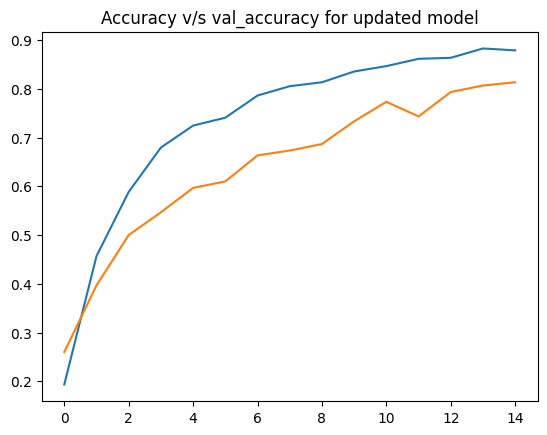

In [23]:
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title("Accuracy v/s val_accuracy for updated model")

Text(0.5, 1.0, 'Accuracy v/s val_accuracy for updated model')

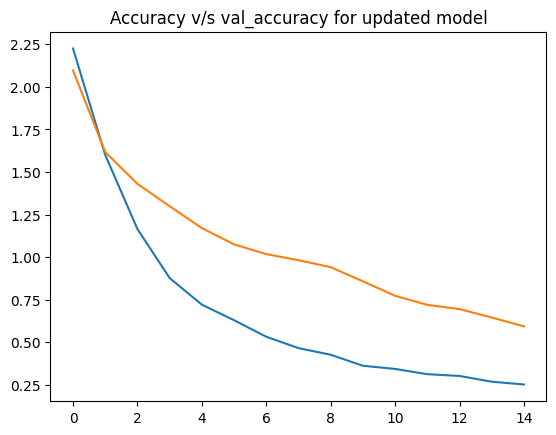

In [24]:
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title("Accuracy v/s val_accuracy for updated model")

## Analogous Study

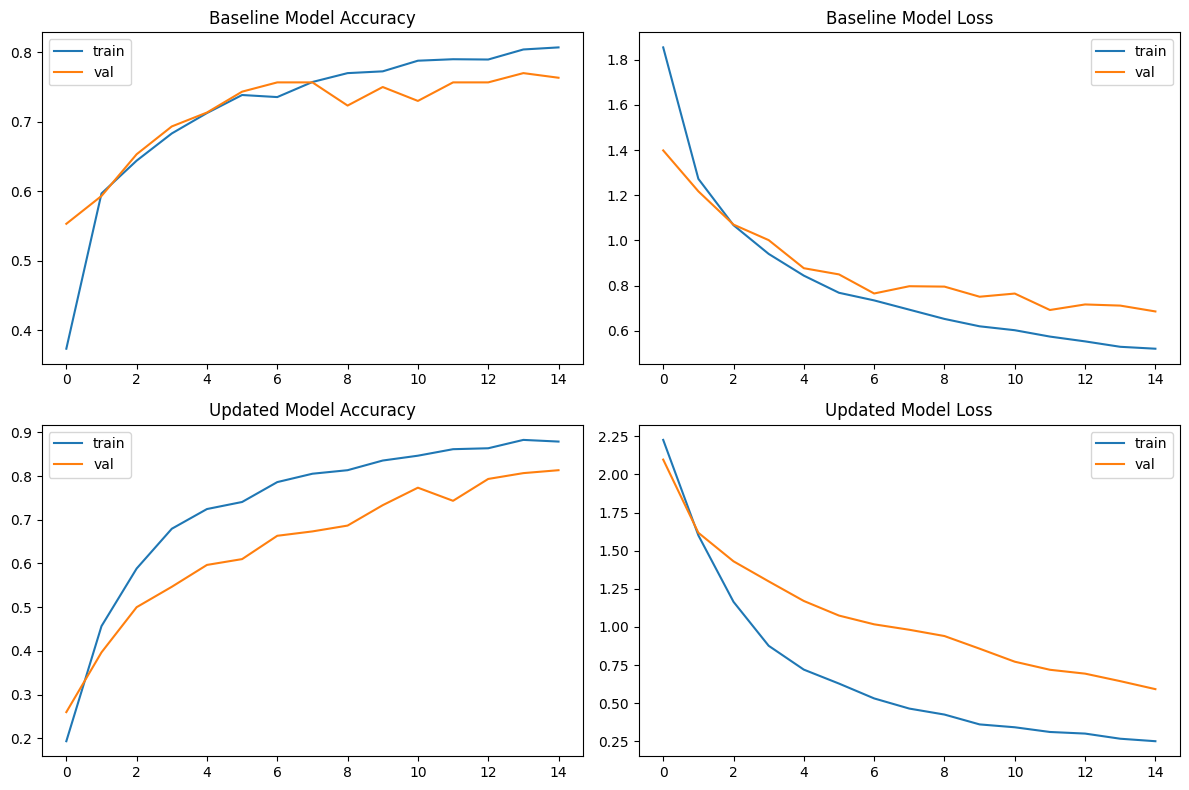

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Row 1: Baseline model ---
# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='train')
axes[0, 0].plot(history.history['val_accuracy'], label='val')
axes[0, 0].set_title("Baseline Model Accuracy")
axes[0, 0].legend()

# Loss
axes[0, 1].plot(history.history['loss'], label='train')
axes[0, 1].plot(history.history['val_loss'], label='val')
axes[0, 1].set_title("Baseline Model Loss")
axes[0, 1].legend()

# --- Row 2: Updated model ---
# Accuracy
axes[1, 0].plot(history_2.history['accuracy'], label='train')
axes[1, 0].plot(history_2.history['val_accuracy'], label='val')
axes[1, 0].set_title("Updated Model Accuracy")
axes[1, 0].legend()

# Loss
axes[1, 1].plot(history_2.history['loss'], label='train')
axes[1, 1].plot(history_2.history['val_loss'], label='val')
axes[1, 1].set_title("Updated Model Loss")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### From the val_accuracy of the updated model we can see that even at 15th epoch, the val_accurtacy seems to keep increasing, this means that the model hasn't stopped learning

Instead of just guessing a higher number of epochs and risk overshooting into actual overfitting, we are going to use a professional machine learning tool: the **ModelCheckpoint callback**. This tells TensorFlow to train the model for a longer run, monitor the validation loss at every single epoch, and automatically save only the absolute best version of your weights.

In [26]:
import tensorflow as tf

# 1. Keep your safety net checkpoint active
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_wound_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# If val_loss doesn't improve for 10 straight epochs, it terminates training
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,             # How many epochs to wait for a genuine breakthrough
    restore_best_weights=True, # Double-guarantee: rewinds the model to the best epoch's weights
    verbose=1
)

# 3. Give it a massive runway of 100 epochs
MAX_EPOCHS = 100

print("Launching guaranteed peak optimization...")
history_final = model_2.fit(
    train_ds,
    validation_data=val_ds_final,
    epochs=MAX_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_callback, early_stopping_callback] # Both shields active
)

Launching guaranteed peak optimization...
Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8926 - loss: 0.2240
Epoch 1: val_loss improved from None to 0.57849, saving model to best_wound_model.keras

Epoch 1: finished saving model to best_wound_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 435ms/step - accuracy: 0.9018 - loss: 0.2138 - val_accuracy: 0.8233 - val_loss: 0.5785
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9112 - loss: 0.1996
Epoch 2: val_loss improved from 0.57849 to 0.55256, saving model to best_wound_model.keras

Epoch 2: finished saving model to best_wound_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 432ms/step - accuracy: 0.9120 - loss: 0.2011 - val_accuracy: 0.8267 - val_loss: 0.5526
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9055 - loss: 0.2054
Epoch 3: val_loss improved from 0.55256 to 0.49286, saving model to best_wound_model.keras

Epoch 3: finished saving model to best_wound_model.keras
74/74 ━━━━━━━━━━━

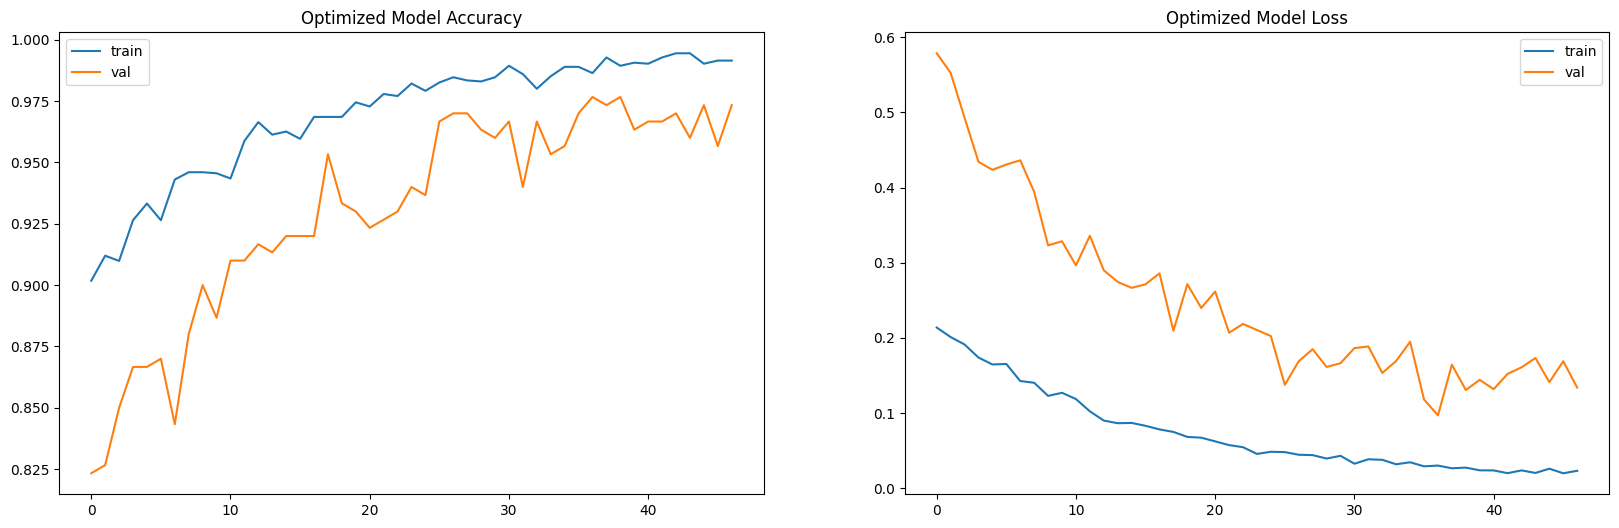

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Accuracy
axes[0].plot(history_final.history['accuracy'], label='train')
axes[0].plot(history_final.history['val_accuracy'], label='val')
axes[0].set_title("Optimized Model Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history_final.history['loss'], label='train')
axes[1].plot(history_final.history['val_loss'], label='val')
axes[1].set_title("Optimized Model Loss")
axes[1].legend()

In [28]:
# 1. Load the saved best model directly from Kaggle's working directory
print("Loading 'best_wound_model.keras' from disk...")
best_model = tf.keras.models.load_model('best_wound_model.keras')
print("Model loaded successfully!")

# 2. Run the final evaluation against the blind test data stream
print("\nEvaluating on the completely blind Test Set...")
test_loss, test_accuracy = best_model.evaluate(test_ds)

# 3. Print out the official production score
print("\n" + "="*40)
print("     OFFICIAL MODEL PERFORMANCE SUMMARY     ")
print("="*40)
print(f"Final Test Loss:     {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print("="*40)

Loading 'best_wound_model.keras' from disk...
Model loaded successfully!

Evaluating on the completely blind Test Set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.9688 - loss: 0.1244

     OFFICIAL MODEL PERFORMANCE SUMMARY     
Final Test Loss:     0.1244
Final Test Accuracy: 96.88%
